In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def root_hist_to_pyhist_errors(th1d, colore, llabel):
    n_bins = th1d.GetNbinsX()
    x_edges = [th1d.GetBinLowEdge(i+1) for i in range(n_bins)]
    x_edges.append(th1d.GetBinLowEdge(n_bins) + th1d.GetBinWidth(n_bins))
    bin_contents = [th1d.GetBinContent(i+1) for i in range(n_bins)]
    bin_errors = [th1d.GetBinError(i+1) for i in range(n_bins)]
    bin_centers =[th1d.GetBinCenter(i+1) for i in range(n_bins)]
    x_bin_errors=[th1d.GetBinWidth(i+1)/2 for i in range(n_bins)]

    
    # Creazione step per linee orizzontali
    x_step = np.repeat(x_edges, 2)[1:-1]
    y_step = np.repeat(bin_contents, 2)
    
    # Aggiunta linee verticali agli estremi
    x_step = np.insert(x_step, 0, x_edges[0])
    y_step = np.insert(y_step, 0, 0)  # parte dal basso
    x_step = np.append(x_step, x_edges[-1])
    y_step = np.append(y_step, 0)     # torna a 0 alla fine
    
    plt.step(x_step, y_step, where='mid', linewidth=3, color=colore, label=llabel, alpha=1)

    if False:
        plt.errorbar(
            bin_centers,
            bin_contents,
            yerr=bin_errors,
            fmt='',           
            markersize=0,
            color=colore,
            ecolor=colore,
            capsize=3,
            alpha=0.7,
            linestyle='none',
            label=None
        )
    
    if False :
        plt.scatter(bin_centers,bin_contents, s=5, color=colore, label=None)
    

In [3]:
file = ROOT.TFile.Open('outfile.root')

h_proba_offbeam = file.Get("h_p_as_pro_OFFBEAM")
h_proba_mc = file.Get("h_p_as_pro_MC")
h_proba_mc_true1muNp = file.Get("h_p_as_pro_true1muNp_MC")

(array([-0.02,  0.  ,  0.02,  0.04,  0.06,  0.08,  0.1 ]),
 [Text(0, -0.02, '−0.02'),
  Text(0, 0.0, '0.00'),
  Text(0, 0.02, '0.02'),
  Text(0, 0.039999999999999994, '0.04'),
  Text(0, 0.06, '0.06'),
  Text(0, 0.08, '0.08'),
  Text(0, 0.09999999999999999, '0.10')])

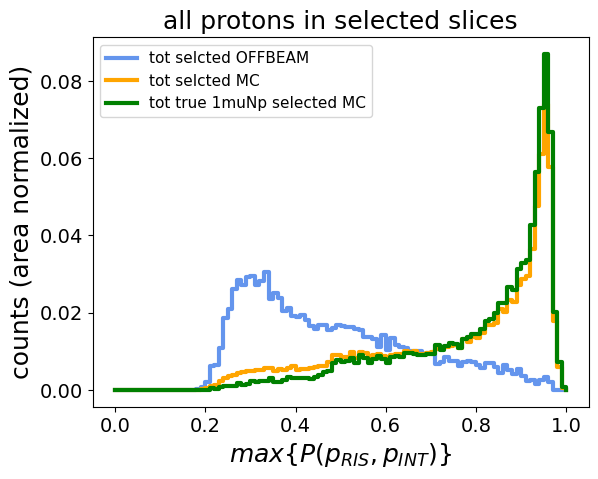

In [4]:
root_hist_to_pyhist_errors(h_proba_offbeam, 'cornflowerblue', 'tot selcted OFFBEAM')
root_hist_to_pyhist_errors(h_proba_mc, 'orange', 'tot selcted MC')
root_hist_to_pyhist_errors(h_proba_mc_true1muNp, 'green', 'tot true 1muNp selected MC')

plt.legend(loc = 'upper left', fontsize = 11)
plt.xlabel(r"$max\{P(p_{RIS},p_{INT})\}$",fontsize=18)
plt.ylabel("counts (area normalized)", fontsize = 18)
plt.title("all protons in selected slices", fontsize = 18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

In [5]:
h_depE_offbeam = file.Get("h_depE_OFFBEAM")
h_depE_mc = file.Get("h_depE_MC")
h_depE_mc_true1muNp = file.Get("h_depE_true1muNp_MC")

(array([-0.01,  0.  ,  0.01,  0.02,  0.03,  0.04,  0.05,  0.06,  0.07,
         0.08]),
 [Text(0, -0.01, '−0.01'),
  Text(0, 0.0, '0.00'),
  Text(0, 0.01, '0.01'),
  Text(0, 0.019999999999999997, '0.02'),
  Text(0, 0.03, '0.03'),
  Text(0, 0.04, '0.04'),
  Text(0, 0.049999999999999996, '0.05'),
  Text(0, 0.060000000000000005, '0.06'),
  Text(0, 0.07, '0.07'),
  Text(0, 0.08, '0.08')])

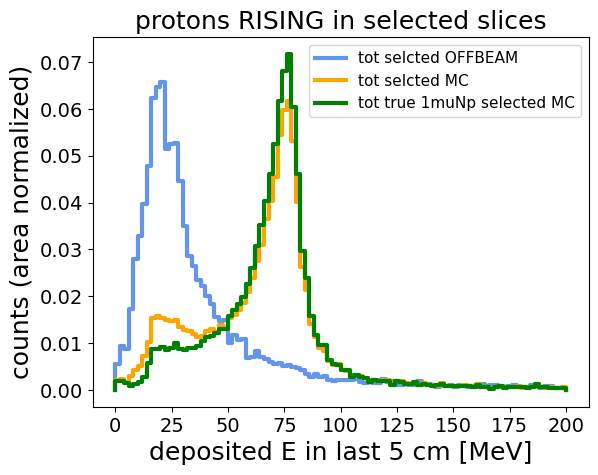

In [6]:
root_hist_to_pyhist_errors(h_depE_offbeam, 'cornflowerblue', 'tot selcted OFFBEAM')
root_hist_to_pyhist_errors(h_depE_mc, 'orange', 'tot selcted MC')
root_hist_to_pyhist_errors(h_depE_mc_true1muNp, 'green', 'tot true 1muNp selected MC')

plt.legend(loc = 'upper right', fontsize = 11)
plt.xlabel("deposited E in last 5 cm [MeV]",fontsize=18)
plt.ylabel("counts (area normalized)", fontsize = 18)
plt.title("protons RISING in selected slices", fontsize = 18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

In [7]:
h_theta_xw_offbeam = file.Get("h_theta_xw_OFFBEAM")
h_theta_xw_mc = file.Get("h_theta_xw_MC")
h_theta_xw_mc_true1muNp = file.Get("h_theta_xw_true1muNp_MC")

(array([-0.01,  0.  ,  0.01,  0.02,  0.03,  0.04,  0.05]),
 [Text(0, -0.01, '−0.01'),
  Text(0, 0.0, '0.00'),
  Text(0, 0.01, '0.01'),
  Text(0, 0.019999999999999997, '0.02'),
  Text(0, 0.03, '0.03'),
  Text(0, 0.04, '0.04'),
  Text(0, 0.049999999999999996, '0.05')])

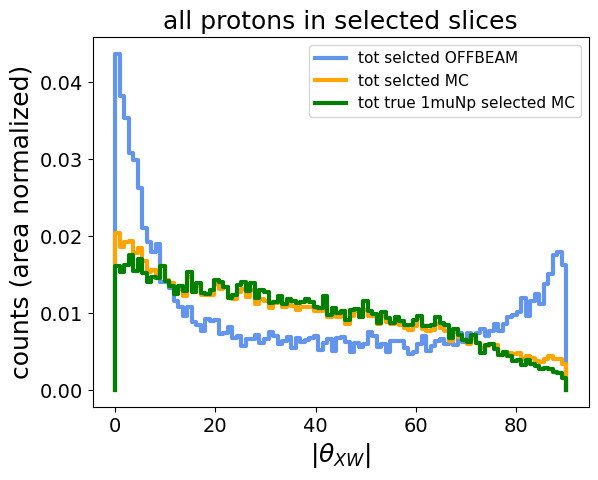

In [8]:
root_hist_to_pyhist_errors(h_theta_xw_offbeam, 'cornflowerblue', 'tot selcted OFFBEAM')
root_hist_to_pyhist_errors(h_theta_xw_mc, 'orange', 'tot selcted MC')
root_hist_to_pyhist_errors(h_theta_xw_mc_true1muNp, 'green', 'tot true 1muNp selected MC')

plt.legend(loc = 'upper right', fontsize = 11)
plt.xlabel(r"|$\theta_{XW}$|",fontsize=18)
plt.ylabel("counts (area normalized)", fontsize = 18)
plt.title("all protons in selected slices", fontsize = 18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

In [9]:
h_crlongtrkdiry_offbeam = file.Get("h_crlongtrkdiry_OFFBEAM")
h_crlongtrkdiry_mc = file.Get("h_crlongtrkdiry_MC")
h_crlongtrkdiry_mc_true1muNp = file.Get("h_crlongtrkdiry_true1muNp_MC")

(-2.0, 2.0)

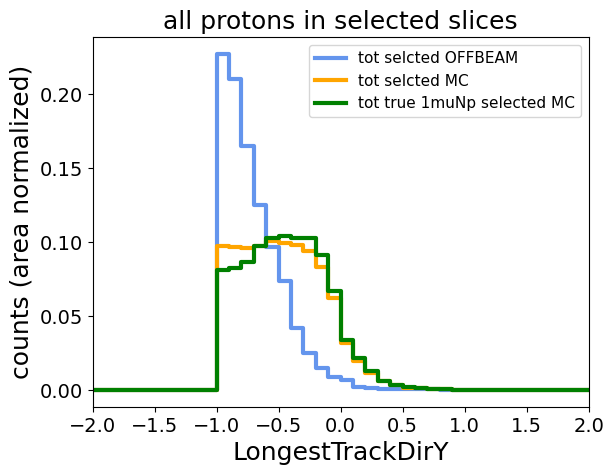

In [10]:
root_hist_to_pyhist_errors(h_crlongtrkdiry_offbeam, 'cornflowerblue', 'tot selcted OFFBEAM')
root_hist_to_pyhist_errors(h_crlongtrkdiry_mc, 'orange', 'tot selcted MC')
root_hist_to_pyhist_errors(h_crlongtrkdiry_mc_true1muNp, 'green', 'tot true 1muNp selected MC')

plt.legend(loc = 'upper right', fontsize = 11)
plt.xlabel("LongestTrackDirY",fontsize=18)
plt.ylabel("counts (area normalized)", fontsize = 18)
plt.title("all protons in selected slices", fontsize = 18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(-2,2)

In [11]:
h_length_offbeam = file.Get("h_length_OFFBEAM")
h_length_mc = file.Get("h_length_MC")
h_length_mc_true1muNp = file.Get("h_length_true1muNp_MC")

(0.0, 50.0)

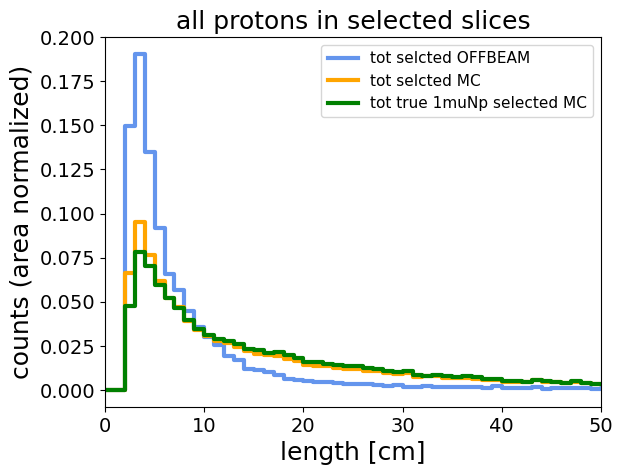

In [15]:
root_hist_to_pyhist_errors(h_length_offbeam, 'cornflowerblue', 'tot selcted OFFBEAM')
root_hist_to_pyhist_errors(h_length_mc, 'orange', 'tot selcted MC')
root_hist_to_pyhist_errors(h_length_mc_true1muNp, 'green', 'tot true 1muNp selected MC')

plt.legend(loc = 'upper right', fontsize = 11)
plt.xlabel("length [cm]",fontsize=18)
plt.ylabel("counts (area normalized)", fontsize = 18)
plt.title("all protons in selected slices", fontsize = 18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0,50)